# 02 — Label Design

**Immunization Defaulter Risk Engine** · Dr. Erick Kiprotich Yegon

Documents and validates the `is_defaulter` label used as the prediction target.

This notebook is deliberately transparent so the label logic can be reviewed by
technical, program, and Ministry of Health stakeholders.

**Primary target definition:**
> A child is labelled a **defaulter** (`is_defaulter = 1`) if, at the time of the
> most recent CHW contact, they satisfy one or more of:
> 1. They have an outstanding immunization follow-up need (`_target_needs_fu`)
> 2. They have at least one positive due-count vaccine (`_target_due_pos`)
> 3. They have missed one or more scheduled vaccines for their age (`_target_missed_flag`)

In [ ]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / ".env")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

df = pd.read_parquet(DATA_PROCESSED / "analytical_dataset.parquet")

# Anonymise county names for portfolio display
_county_order = sorted(df["county"].dropna().unique())
_county_map = {name: f"County {chr(65 + i)}" for i, name in enumerate(_county_order)}
df["county"] = df["county"].map(_county_map).fillna(df["county"])

print(f"Loaded {df.shape[0]:,} patient records")

## 1. Composite label construction

In [2]:
# Three sub-signals that compose the final label
sub_flags = ["_target_needs_fu", "_target_due_pos", "_target_missed_flag"]

flag_summary = pd.DataFrame([
    {
        "sub_flag"     : col,
        "description"  : {
            "_target_needs_fu"     : "CHW recorded active immunization follow-up need",
            "_target_due_pos"      : "due_count_clean > 0 (outstanding vaccines at contact)",
            "_target_missed_flag"  : "Missed ≥1 age-expected vaccine (vax_completeness_score < 1)",
        }[col],
        "positive_n"   : int(df[col].sum()) if col in df.columns else None,
        "positive_pct" : round(df[col].mean() * 100, 1) if col in df.columns else None,
    }
    for col in sub_flags if col in df.columns
])

print("Sub-flag prevalence (each child may satisfy multiple):")
display(flag_summary)

# Final composite label
print(f"\nFinal is_defaulter (union of sub-flags):")
print(df["is_defaulter"].value_counts().rename(index={0: "Non-defaulter (0)", 1: "Defaulter (1)"}))
print(f"  Prevalence: {df['is_defaulter'].mean():.1%}")

Sub-flag prevalence (each child may satisfy multiple):


,sub_flag,description,positive_n,positive_pct
0,_target_needs_fu,CHW recorded active immunization follow-up need,1032,15.0000
1,_target_due_pos,due_count_clean > 0 (outstanding vaccines at c...,110,1.6000
2,_target_missed_flag,Missed ≥1 age-expected vaccine (vax_completene...,180,2.6000



Final is_defaulter (union of sub-flags):
is_defaulter
Non-defaulter (0)    5733
Defaulter (1)        1131
Name: count, dtype: int64
  Prevalence: 16.5%


In [3]:
# Venn-style overlap between sub-flags
if all(c in df.columns for c in sub_flags):
    overlap = pd.crosstab(
        df["_target_needs_fu"].astype(int).astype(str).radd("fu="),
        df["_target_due_pos"].astype(int).astype(str).radd("due="),
        margins=True,
    )
    print("Overlap: needs_follow_up × due_count_positive")
    display(overlap)

    only_one = (
        (df[sub_flags].sum(axis=1) == 1).sum(),
        (df[sub_flags].sum(axis=1) == 2).sum(),
        (df[sub_flags].sum(axis=1) == 3).sum(),
    )
    print(f"\nAmong defaulters: exactly 1 flag={only_one[0]}, 2 flags={only_one[1]}, all 3={only_one[2]}")

Overlap: needs_follow_up × due_count_positive


_target_due_pos,due=0,due=1,All
_target_needs_fu,,,
fu=0,5776,56,5832
fu=1,978,54,1032
All,6754,110,6864



Among defaulters: exactly 1 flag=994, 2 flags=83, all 3=54


## 2. Prevalence by age band

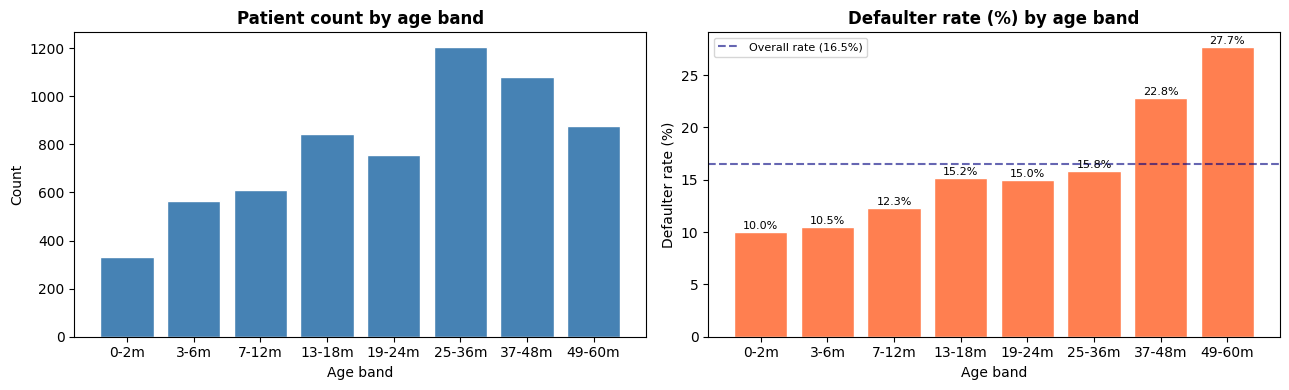

,age_band,n_patients,defaulter_rate,n_defaulters,defaulter_pct
0,0-2m,331,0.0997,33,10.0000
1,3-6m,563,0.1048,59,10.5000
2,7-12m,612,0.1225,75,12.3000
3,13-18m,844,0.1517,128,15.2000
4,19-24m,758,0.1504,114,15.0000
5,25-36m,1206,0.1575,190,15.8000
6,37-48m,1079,0.2280,246,22.8000
7,49-60m,878,0.2768,243,27.7000


In [4]:
age = pd.to_numeric(df["patient_age_in_months"], errors="coerce")
bins = [0, 2, 6, 12, 18, 24, 36, 48, 61]
labels = ["0-2m","3-6m","7-12m","13-18m","19-24m","25-36m","37-48m","49-60m"]
df["age_band"] = pd.cut(age, bins=bins, labels=labels, right=True)

age_prev = df.groupby("age_band", observed=True).agg(
    n_patients     = ("patient_id", "count"),
    defaulter_rate = ("is_defaulter", "mean"),
    n_defaulters   = ("is_defaulter", "sum"),
).reset_index()
age_prev["defaulter_pct"] = (age_prev["defaulter_rate"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(age_prev["age_band"].astype(str), age_prev["n_patients"],
            color="steelblue", edgecolor="white")
axes[0].set_title("Patient count by age band", fontweight="bold")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("Count")

bars = axes[1].bar(age_prev["age_band"].astype(str), age_prev["defaulter_pct"],
                   color="coral", edgecolor="white")
axes[1].set_title("Defaulter rate (%) by age band", fontweight="bold")
axes[1].set_xlabel("Age band")
axes[1].set_ylabel("Defaulter rate (%)")
axes[1].axhline(df["is_defaulter"].mean() * 100, color="navy",
                linestyle="--", alpha=0.6, label=f"Overall rate ({df['is_defaulter'].mean():.1%})")
axes[1].legend(fontsize=8)

for bar, pct in zip(bars, age_prev["defaulter_pct"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{pct}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()
age_prev

## 3. Prevalence by county

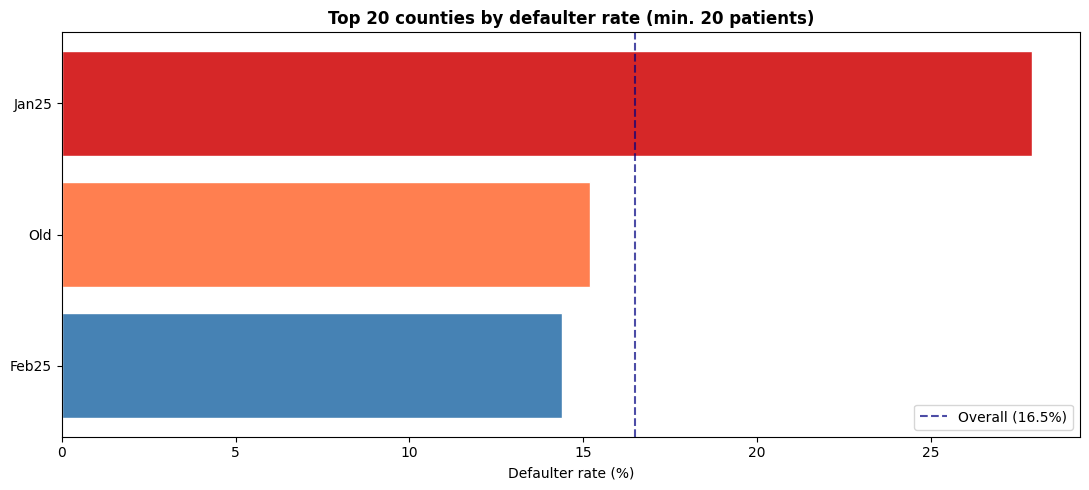

Counties with defaulter rate >25%: 1
Counties with defaulter rate <10%: 0


In [5]:
county_prev = df.groupby("county").agg(
    n_patients     = ("patient_id", "count"),
    defaulter_rate = ("is_defaulter", "mean"),
).query("n_patients >= 20").sort_values("defaulter_rate", ascending=False).reset_index()
county_prev["defaulter_pct"] = (county_prev["defaulter_rate"] * 100).round(1)

top20 = county_prev.head(20)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#d62728" if r > 0.25 else "coral" if r > 0.15 else "steelblue"
          for r in top20["defaulter_rate"]]
ax.barh(top20["county"][::-1], top20["defaulter_pct"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(df["is_defaulter"].mean() * 100, color="navy", linestyle="--",
           alpha=0.7, label=f"Overall ({df['is_defaulter'].mean():.1%})")
ax.set_title("Top 20 counties by defaulter rate (min. 20 patients)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Defaulter rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Counties with defaulter rate >25%: {(county_prev.defaulter_rate > 0.25).sum()}")
print(f"Counties with defaulter rate <10%: {(county_prev.defaulter_rate < 0.10).sum()}")

## 4. Label sanity checks

In [6]:
# Defaulters should have more outstanding vaccines and lower completeness
sanity_cols = [
    "due_count_clean", "vax_completeness_score", "vax_completeness_all",
    "age_expected_vaccine_count", "vax_received_core",
]

sanity = df.groupby("is_defaulter")[[
    c for c in sanity_cols if c in df.columns
]].mean().round(3).rename(index={0: "Non-defaulter", 1: "Defaulter"})

print("Mean values by target class (sanity check):")
display(sanity)

Mean values by target class (sanity check):


,due_count_clean,vax_completeness_score,vax_completeness_all,age_expected_vaccine_count,vax_received_core
is_defaulter,,,,,
Non-defaulter,0.0000,0.6420,0.5750,15.4720,10.0470
Defaulter,0.6220,0.5170,0.4510,15.9130,8.5690


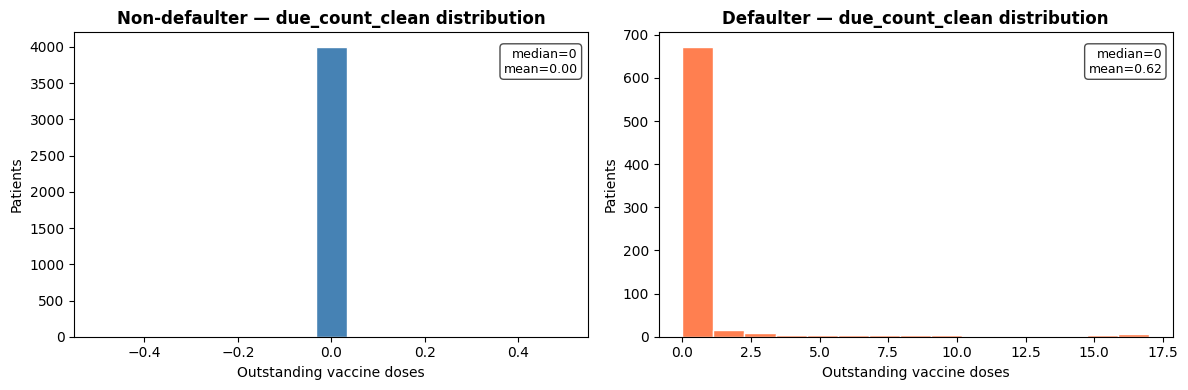

In [7]:
# Distribution of due_count_clean by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, grp) in zip(axes, df.groupby("is_defaulter")):
    vals = pd.to_numeric(grp["due_count_clean"], errors="coerce").dropna()
    name = "Defaulter" if label == 1 else "Non-defaulter"
    color = "coral" if label == 1 else "steelblue"
    ax.hist(vals, bins=15, color=color, edgecolor="white")
    ax.set_title(f"{name} — due_count_clean distribution", fontweight="bold")
    ax.set_xlabel("Outstanding vaccine doses")
    ax.set_ylabel("Patients")
    ax.text(0.98, 0.95, f"median={vals.median():.0f}\nmean={vals.mean():.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()

## 5. Temporal trend — defaulter rate by month

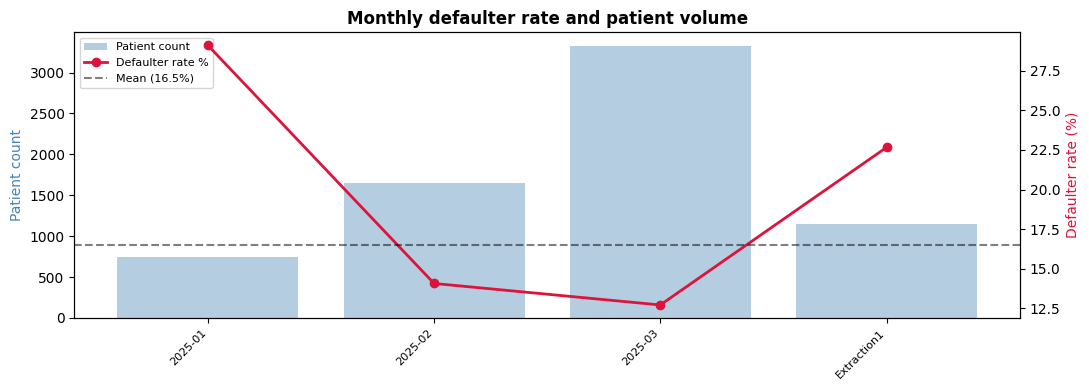

In [8]:
monthly = df.groupby("month_clean").agg(
    n=("patient_id", "count"),
    defaulter_rate=("is_defaulter", "mean"),
).reset_index().sort_values("month_clean")

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(range(len(monthly)), monthly["n"], color="steelblue", alpha=0.4, label="Patient count")
ax2.plot(range(len(monthly)), monthly["defaulter_rate"] * 100,
         color="crimson", marker="o", linewidth=2, label="Defaulter rate %")
ax2.axhline(df["is_defaulter"].mean() * 100, color="black", linestyle="--",
            alpha=0.5, label=f"Mean ({df['is_defaulter'].mean():.1%})")

ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly["month_clean"], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Patient count", color="steelblue")
ax2.set_ylabel("Defaulter rate (%)", color="crimson")
ax1.set_title("Monthly defaulter rate and patient volume",
              fontsize=12, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Label design notes

| Consideration | Decision |
|---|---|
| **Definition** | Union of 3 complementary signals (follow-up flag, due count, missed-vaccine flag) — robust to any single-signal failure |
| **Prevalence** | ~16.5% positive class — moderate imbalance; handled with `scale_pos_weight` in XGBoost |
| **Age pattern** | Defaulter rates peak in the 7–18 month window (pentavalent booster period) — expected from vaccine schedule |
| **Geographic variation** | Substantial county-level variation (5%–40%) — geographic encoding is a meaningful predictor |
| **Temporal stability** | No major month-to-month spikes — label is not driven by a single collection event |
| **Leakage risk** | None — label is constructed from the same visit record; no future data used |
| **Sanity** | Defaulters have higher mean due_count and lower vaccine completeness — label is directionally correct |